<a href="https://colab.research.google.com/github/ochilovu2010/IOAI/blob/main/Topics/Convolutional_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!ls

dog_and_cat_1.zip  dog_and_cat_2.zip  sample_data


In [ ]:
!unzip dog_and_cat_1.zip

Archive:  dog_and_cat_1.zip
  inflating: train.csv               
  inflating: train/cat/Abyssinian_127_jpg.rf.b2553880d73a78e26e396fe7775f31be.jpg  
  inflating: train/cat/Abyssinian_131_jpg.rf.3aeee0801499f335e3a59b51189e1351.jpg  
  inflating: train/cat/Abyssinian_149_jpg.rf.b6b4a72a93f8bc2b239b18c5d181190c.jpg  
  inflating: train/cat/Abyssinian_15_jpg.rf.7bc44eeb9865e35cb1d5f9ef4f53b381.jpg  
  inflating: train/cat/Abyssinian_167_jpg.rf.1d367cb1cf82c1e5ebda79fda928cee5.jpg  
  inflating: train/cat/Bengal_103_jpg.rf.bb684501a53abf381a6bf07f9cd2243c.jpg  
  inflating: train/cat/Bengal_109_jpg.rf.aed42b8605ef92b579992d02e2e2cc4c.jpg  
  inflating: train/cat/Bengal_116_jpg.rf.8c6280ad977c6c749da4d35156e49286.jpg  
  inflating: train/cat/Bengal_13_jpg.rf.7c75131d257406a75d8d676dd9b5f5f7.jpg  
  inflating: train/cat/Bengal_145_jpg.rf.3dadbfbb39437890fc249f7edb37cb2f.jpg  
  inflating: train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae66bae50a857aca.jpg  
  inflating: train/cat/Bengal_165_jp

In [ ]:
!unzip dog_and_cat_2.zip

Archive:  dog_and_cat_2.zip
  inflating: train_transformed/cat1.jpg  
  inflating: train_transformed/cat10.jpg  
  inflating: train_transformed/cat100.jpg  
  inflating: train_transformed/cat1000.jpg  
  inflating: train_transformed/cat101.jpg  
  inflating: train_transformed/cat102.jpg  
  inflating: train_transformed/cat103.jpg  
  inflating: train_transformed/cat104.jpg  
  inflating: train_transformed/cat105.jpg  
  inflating: train_transformed/cat106.jpg  
  inflating: train_transformed/cat107.jpg  
  inflating: train_transformed/cat108.jpg  
  inflating: train_transformed/cat109.jpg  
  inflating: train_transformed/cat11.jpg  
  inflating: train_transformed/cat110.jpg  
  inflating: train_transformed/cat111.jpg  
  inflating: train_transformed/cat112.jpg  
  inflating: train_transformed/cat113.jpg  
  inflating: train_transformed/cat114.jpg  
  inflating: train_transformed/cat115.jpg  
  inflating: train_transformed/cat116.jpg  
  inflating: train_transformed/cat117.jpg  
  infla

In [ ]:

transformer = A.Compose([
    A.Resize(height=256, width=256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transformer = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
class dataset(Dataset):
  def __init__(self, transformer):
    first_dataset = "/content/train"
    second_dataset = "/content/train_transformed"
    self.transform = transformer
    self.data = []
    self.label = []
    self.class2idx = {"cat":0, "dog":1}
    for name in os.listdir(first_dataset):
      second_path = os.path.join(first_dataset, name)
      for final in os.listdir(second_path):
        self.data.append(os.path.join(second_path, final))
        self.label.append(self.class2idx[name])
    for name in os.listdir(second_dataset):
      label = name[:3]
      self.data.append(os.path.join(second_dataset, name))
      self.label.append(self.class2idx[label])
  def __len__(self):
    return len(self.data)
  def __getitem__(self, x):
    img = Image.open(self.data[x]).convert("RGB")
    label = self.label[x]
    img_transformed = self.transform(image = np.array(img))
    return img_transformed['image'], torch.tensor(label, dtype = torch.long)

In [ ]:
data = dataset(transformer)

In [ ]:
img, label = data[2000]
print(img.shape)

torch.Size([3, 256, 256])


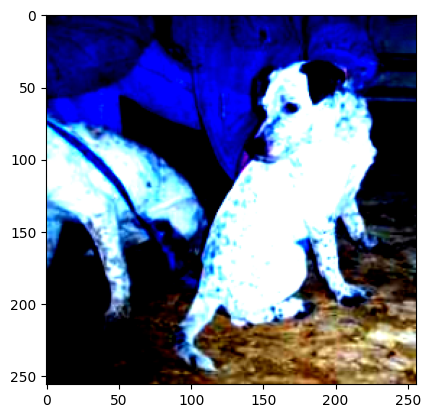

In [ ]:
plt.imshow(img.permute(1,2,0))

In [ ]:
print(label)

tensor(1)


In [ ]:
loader = DataLoader(data, batch_size = 16, shuffle = True)

In [ ]:

import torch.nn.functional as F
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride = 1):
    super().__init__()
    self.batchnorm1 = nn.BatchNorm2d(out_channels)
    self.batchnorm2 = nn.BatchNorm2d(out_channels)
    self.conv1 = nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = 3, stride = stride, padding = 1, bias = True)
    self.conv2 = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = 3, stride = 1, padding = 1, bias = True)
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels !=out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels = in_channels, out_channels = out_channels, stride = stride, kernel_size = 1, bias = True),
          nn.BatchNorm2d(out_channels),
      )
  def forward(self, x):
    out = F.relu(self.batchnorm1(self.conv1(x)))
    out = self.batchnorm2(self.conv2(out))

    out += self.shortcut(x)
    return F.relu(out)

In [ ]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = nn.Sequential(
            ResBlock(64, 64, stride=1),
            ResBlock(64, 64, stride=1),
            ResBlock(64, 64, stride=1)
        )

        self.layer2 = nn.Sequential(
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=1),
            ResBlock(128, 128, stride=1),
            ResBlock(128, 128, stride=1)
        )

        self.layer3 = nn.Sequential(
            ResBlock(128, 256, stride=2),
            ResBlock(256, 256, stride=1),
            ResBlock(256, 256, stride=1),
            ResBlock(256, 256, stride=1),
            ResBlock(256, 256, stride=1),
            ResBlock(256, 256, stride=1)
        )

        self.layer4 = nn.Sequential(
            ResBlock(256, 512, stride=2),
            ResBlock(512, 512, stride=1),
            ResBlock(512, 512, stride=1)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyModel().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from tqdm import tqdm
epochs = 10
for epoch in range(epochs):
  pbar = tqdm(loader)
  losses = []
  for img, label in pbar:
    optimizer.zero_grad()
    img = img.to(device)
    label = label.to(device).unsqueeze(1).float()
    predictions = model(img)
    loss = criterion(predictions, label)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
  if len(losses) > 0:
    print(f"Epoch {epoch+1} Loss: {sum(losses)/len(losses):.4f}")
  else:
    print(f"Epoch {epoch+1}: No losses recorded.")

100%|██████████| 143/143 [00:19<00:00,  7.25it/s]


Epoch 1 Loss: 0.4215


100%|██████████| 143/143 [00:20<00:00,  7.09it/s]


Epoch 2 Loss: 0.4076


100%|██████████| 143/143 [00:19<00:00,  7.19it/s]


...

Epoch 8 Loss: 0.3966


100%|██████████| 143/143 [00:19<00:00,  7.19it/s]


Epoch 9 Loss: 0.3997


100%|██████████| 143/143 [00:19<00:00,  7.30it/s]

Epoch 10 Loss: 0.3788


In [ ]:
class val_dataset(Dataset):
  def __init__(self, transformer):
    first_dataset = "/content/val"
    self.transform = transformer
    self.data = []
    self.label = []
    self.class2idx = {"cat":0, "dog":1}
    for name in os.listdir(first_dataset):
      second_path = os.path.join(first_dataset, name)
      for final in os.listdir(second_path):
        self.data.append(os.path.join(second_path, final))
        self.label.append(self.class2idx[name])
  def __len__(self):
    return len(self.data)
  def __getitem__(self, x):
    img = Image.open(self.data[x]).convert("RGB")
    label = self.label[x]
    img_transformed = self.transform(image = np.array(img))
    return img_transformed['image'], torch.tensor(label, dtype = torch.long)

In [ ]:
validation = val_dataset(val_transformer)
tta_transforms = [
    A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),

    A.Compose([
        A.Resize(256, 256),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),

    A.Compose([
        A.Resize(256, 256),
        A.Rotate(limit=(10,10), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),

    A.Compose([
        A.Resize(256, 256),
        A.Rotate(limit=(-10,-10), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]
model.eval()

correct = 0
total = len(validation)

with torch.no_grad():

    for idx in range(len(validation)):

        img_path = validation.data[idx]

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        label = validation.label[idx]

        probs = []

        for transform in tta_transforms:

            x = transform(image=image)["image"]
            x = x.unsqueeze(0).to(device)

            logit = model(x)

            prob = torch.sigmoid(logit)

            probs.append(prob.item())

        mean_prob = np.mean(probs)

        prediction = 1 if mean_prob > 0.5 else 0

        if prediction == label:
            correct += 1

accuracy = correct / total

print(f"Accuracy = {accuracy:.4f}")

Accuracy = 0.6714


In [ ]:
state_dict = model.state_dict()

In [ ]:
torch.save(state_dict, 'best_model.pth')

In [ ]:
!ls

best_model.path  dog_and_cat_1.zip  sample_data  train.csv	    val
best_model.pth	 dog_and_cat_2.zip  train	 train_transformed  val.csv
